In [1]:
import pandas as pd
import numpy as np
import ast

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

In [2]:
movies = pd.read_csv(
    "../data/movies_metadata.csv",
    low_memory=False
)

movies["budget"] = pd.to_numeric(
    movies["budget"],
    errors="coerce"
)

movies["revenue"] = pd.to_numeric(
    movies["revenue"],
    errors="coerce"
)

movies["release_date"] = pd.to_datetime(
    movies["release_date"],
    errors="coerce"
)

financial = movies[
    (movies["budget"] > 0) &
    (movies["revenue"] > 0)
].copy()

financial["profitable"] = (
    financial["revenue"] > financial["budget"]
).astype(int)

In [ ]:
financial["release_year"] = financial["release_date"].dt.year
financial["release_month"] = financial["release_date"].dt.month

financial["has_collection"] = (
    financial["belongs_to_collection"].notna()
).astype(int)

financial["genre_list"] = financial["genres"].apply(
    lambda x: [g["name"] for g in ast.literal_eval(x)]
)
genre_dummies = financial["genre_list"].apply(
    lambda genres: pd.Series({genre: 1 for genre in genres})
).fillna(0)

genre_dummies = genre_dummies.add_prefix("genre_")

financial = pd.concat([financial, genre_dummies], axis=1)

financial["log_budget"] = np.log1p(financial["budget"])

In [ ]:
genre_features = [
    col for col in financial.columns
    if col.startswith("genre_")
]

features = [
    "log_budget",
    "runtime",
    "release_year",
    "release_month",
    "original_language",
    "has_collection"
] + genre_features

X = financial[features]
y = financial["profitable"]

print(X.shape)
X.head()

(5381, 7)


,log_budget,runtime,release_year,release_month,original_language,primary_genre,has_collection
0,17.216708,81.0,1995,10,en,Animation,1
1,17.989898,104.0,1995,12,en,Adventure,0
3,16.588099,127.0,1995,12,en,Comedy,0
5,17.909855,170.0,1995,12,en,Action,0
8,17.370859,106.0,1995,12,en,Action,0


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training:", len(X_train))
print("Testing:", len(X_test))

Training: 4304
Testing: 1077


In [ ]:
numeric_features = [
    "log_budget",
    "runtime",
    "release_year",
    "release_month",
    "has_collection"
] + genre_features

categorical_features = [
    "original_language"
]

numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

In [7]:
logistic_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        max_iter=1000,
        random_state=42
    ))
])

logistic_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['log_budget', 'runtime',
                                                   'release_year',
                                                   'release_month',
                                                   'has_collection']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['original_language',
                                                   'primary_genre'])])),
                ('classifier',
                 LogisticRegression(max_iter=1000, random_state=42))])

In [8]:
log_pred = logistic_model.predict(X_test)
log_prob = logistic_model.predict_proba(X_test)[:, 1]

In [9]:
print("Logistic Regression")
print("-------------------")
print("Accuracy:", round(accuracy_score(y_test, log_pred), 3))
print("Precision:", round(precision_score(y_test, log_pred), 3))
print("Recall:", round(recall_score(y_test, log_pred), 3))
print("F1:", round(f1_score(y_test, log_pred), 3))
print("ROC-AUC:", round(roc_auc_score(y_test, log_prob), 3))

Logistic Regression
-------------------
Accuracy: 0.697
Precision: 0.708
Recall: 0.963
F1: 0.816
ROC-AUC: 0.68


In [12]:
random_forest_unbalanced = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=300,
        max_depth=10,
        min_samples_leaf=5,
        random_state=42
    ))
])

random_forest_unbalanced.fit(X_train, y_train)

rf2_pred = random_forest_unbalanced.predict(X_test)
rf2_prob = random_forest_unbalanced.predict_proba(X_test)[:, 1]

print("Random Forest - No Class Weight")
print("--------------------------------")
print("Accuracy:", round(accuracy_score(y_test, rf2_pred), 3))
print("Precision:", round(precision_score(y_test, rf2_pred), 3))
print("Recall:", round(recall_score(y_test, rf2_pred), 3))
print("F1:", round(f1_score(y_test, rf2_pred), 3))
print("ROC-AUC:", round(roc_auc_score(y_test, rf2_prob), 3))

Random Forest - No Class Weight
--------------------------------
Accuracy: 0.701
Precision: 0.7
Recall: 1.0
F1: 0.824
ROC-AUC: 0.723


In [13]:
feature_names = random_forest.named_steps[
    "preprocessor"
].get_feature_names_out()

# Get Random Forest feature importances
importances = random_forest.named_steps[
    "classifier"
].feature_importances_

feature_importance = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values(
    "importance",
    ascending=False
)

feature_importance.head(15)

,feature,importance
4,num__has_collection,0.309606
0,num__log_budget,0.190635
2,num__release_year,0.177666
1,num__runtime,0.096079
3,num__release_month,0.063070
48,cat__primary_genre_Drama,0.032658
15,cat__original_language_fr,0.013715
45,cat__primary_genre_Comedy,0.013353
17,cat__original_language_hi,0.012374
53,cat__primary_genre_Horror,0.010232


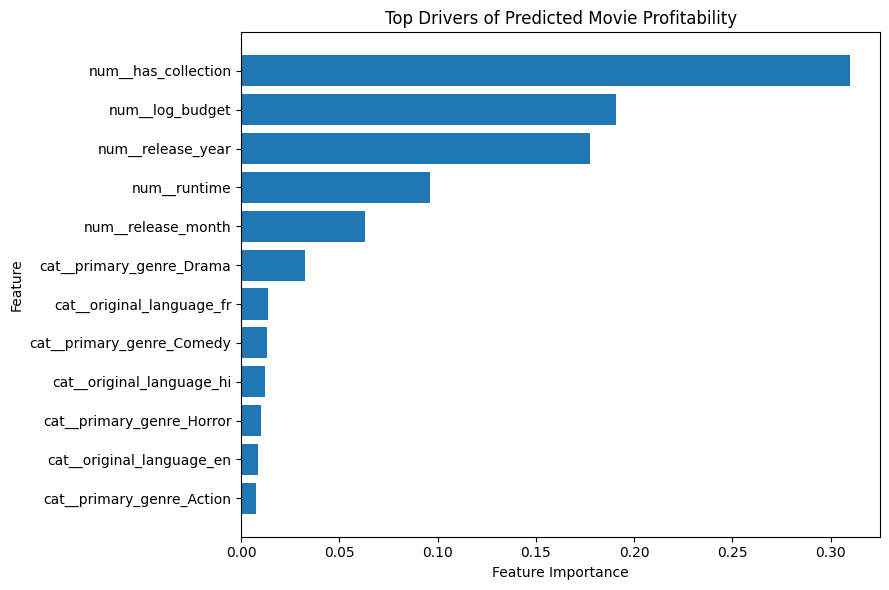

In [ ]:
import matplotlib.pyplot as plt

top_features = feature_importance.head(12).sort_values(
    "importance"
)

plt.figure(figsize=(9, 6))

plt.barh(
    top_features["feature"],
    top_features["importance"]
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Top Drivers of Predicted Movie Profitability")

plt.tight_layout()
plt.show()

In [11]:
rf_pred = random_forest.predict(X_test)
rf_prob = random_forest.predict_proba(X_test)[:, 1]

print("Random Forest")
print("-------------")
print("Accuracy:", round(accuracy_score(y_test, rf_pred), 3))
print("Precision:", round(precision_score(y_test, rf_pred), 3))
print("Recall:", round(recall_score(y_test, rf_pred), 3))
print("F1:", round(f1_score(y_test, rf_pred), 3))
print("ROC-AUC:", round(roc_auc_score(y_test, rf_prob), 3))

Random Forest
-------------
Accuracy: 0.604
Precision: 0.841
Recall: 0.533
F1: 0.653
ROC-AUC: 0.724


In [10]:
random_forest = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=300,
        max_depth=10,
        min_samples_leaf=5,
        random_state=42,
        class_weight="balanced"
    ))
])

random_forest.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['log_budget', 'runtime',
                                                   'release_year',
                                                   'release_month',
                                                   'has_collection']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['original_language',
                                                   'primary_genre'])])),
                ('classifier',
                 RandomForestClassifier(class_weight='balanced', max_depth=10,
                                        min_samples_leaf=5, n_estimators=300,
                                        random_state=42))])